# Objective
* **I am aiming to make a model that can classify skin cancer, whether a given image of skin `cancer malignant` or `cancer benign`.**
* **I am will TinyVGG architecture to train my model.**

## Note:
* Our model is 

### Importing Important Libraries, modules and Dependency Here.

In [75]:
import torch
import torch.nn as nn

In [76]:
from torchvision import datasets, transforms

In [77]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
torch.cuda.get_device_name()

Device: cuda


'NVIDIA GeForce RTX 2050'

In [85]:
# Write a transform for image
data_tranforms = transforms.Compose([
    # Resize our image to 64*64
    transforms.Resize(size=(64,64)),
    # Flip the image randomly on the horizontal
    transforms.RandomHorizontalFlip(p=0.5),
    #Normalize the dataset
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                     std=[0.5, 0.5, 0.5]),
    # turn the image into a torch.Tensor
])

malignant ->4000
benign -> 5200

In [86]:
train_dir = f"../../../../GitClones/Cancer_Binary_Classification/skin_dataset_resized/train_set"
test_dir = f"../../../../GitClones/Cancer_Binary_Classification/skin_dataset_resized/test_set"
val_dir = f"../../../../GitClones/Cancer_Binary_Classification/skin_dataset_resized/val_set"

In [87]:
train_data = datasets.ImageFolder(root=train_dir, transform=data_tranforms)
test_data = datasets.ImageFolder(root=test_dir, transform=data_tranforms)
val_data = datasets.ImageFolder(root=val_dir, transform=data_tranforms)

In [88]:
train_data

Dataset ImageFolder
    Number of datapoints: 9200
    Root location: ../../../../GitClones/Cancer_Binary_Classification/skin_dataset_resized/train_set
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
               Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
           )

In [89]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32
train_dataloader = DataLoader(dataset= train_data,
                              batch_size=BATCH_SIZE,
                              shuffle=True)
test_dataloader = DataLoader(dataset=test_data,
                             batch_size=BATCH_SIZE,
                             shuffle=False)
val_dataloader = DataLoader(dataset=val_data,
                            batch_size=BATCH_SIZE,
                            shuffle=True)

train_dataloader, test_dataloader, val_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x1cda1697ee0>,
 <torch.utils.data.dataloader.DataLoader at 0x1cda1696a10>)

In [90]:
images, labels = next(iter(train_dataloader))
images.shape, labels

(torch.Size([32, 3, 64, 64]),
 tensor([0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0,
         1, 0, 1, 0, 0, 0, 1, 0]))

In [91]:
class_names = train_data.class_to_idx

In [92]:
img, label = train_data[0][0], train_data[0][1]
print(f"Image shape: {img.shape}")
print(f"Image dtype: {img.dtype}")
print(f"Label: {label}")
print(f"Label dtype: {type(label)}")


Image shape: torch.Size([3, 64, 64])
Image dtype: torch.float32
Label: 0
Label dtype: <class 'int'>


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.7176471..1.0].


(-0.5, 63.5, 63.5, -0.5)

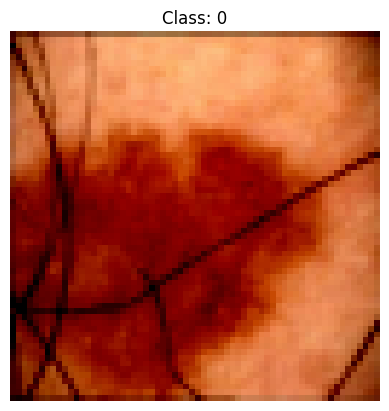

In [93]:
import matplotlib.pyplot as plt

plt.imshow(img.permute(1,2,0))
plt.title(f"Class: {label}")
plt.axis(False)

In [94]:
torch.manual_seed(42)
random_samples = torch.randint(0,9499,(7,))
random_samples

tensor([ 890, 4223, 8740, 8853, 5996, 7871,  803])

In [95]:
train_data[1000][0].shape

torch.Size([3, 64, 64])

In [96]:
len(random_samples)

7

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5137255..0.8039216].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9372549..0.39607847].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.85882354..0.5529412].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.67058825..0.56078434].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.6862745..0.8980392].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.73333335..0.99215686].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.

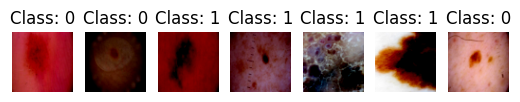

In [97]:
for i in random_samples:
    img, label = train_data[i][0], train_data[i][1] # type: ignore

    plt.subplot(1, len(random_samples), torch.where(random_samples == i)[0].item() + 1)
    plt.imshow(img.permute(1,2,0))
    plt.title(f"Class: {label}")
    plt.axis(False)

## 1. Build and Train TinyVGG

In [98]:
class TinyVGG(nn.Module):
    def __init__(self, in_channels=3, hidden_units=64, out_features=1):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels, hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(hidden_units * 16 * 16, out_features)  # for 64x64 input
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.classifier(x)
        return x


## 2. Setup Loss, Optimizer, and Accuracy

In [99]:
model = TinyVGG().to(device)

loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def binary_accuracy(preds, labels):
    preds = torch.round(torch.sigmoid(preds))
    correct = (preds == labels).float()
    return correct.sum() / len(correct)


## 3. Training Loop

In [100]:
def train(model, dataloader, loss_fn, optimizer, device):
    model.train()
    total_loss, total_acc = 0, 0

    for X, y in dataloader:
        X, y = X.to(device), y.float().unsqueeze(1).to(device)
        preds = model(X)
        loss = loss_fn(preds, y)
        acc = binary_accuracy(preds, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc += acc.item()

    return total_loss / len(dataloader), total_acc / len(dataloader)


# 4. Evaluation Function

In [101]:
def evaluate(model, dataloader, loss_fn, device):
    model.eval()
    total_loss, total_acc = 0, 0

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.float().unsqueeze(1).to(device)
            preds = model(X)
            loss = loss_fn(preds, y)
            acc = binary_accuracy(preds, y)

            total_loss += loss.item()
            total_acc += acc.item()

    return total_loss / len(dataloader), total_acc / len(dataloader)


In [102]:
## 5. Train the model

In [103]:
epochs = 10

for epoch in range(epochs):
    train_loss, train_acc = train(model, train_dataloader, loss_fn, optimizer, device)
    val_loss, val_acc = evaluate(model, val_dataloader, loss_fn, device)

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc*100:.2f}%")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc*100:.2f}%")


Epoch 1/10
Train Loss: 0.3358, Train Acc: 86.07%
Val Loss: 0.5624, Val Acc: 70.92%
Epoch 2/10
Train Loss: 0.2839, Train Acc: 88.76%
Val Loss: 0.3259, Val Acc: 87.89%
Epoch 3/10
Train Loss: 0.2552, Train Acc: 90.13%
Val Loss: 0.2679, Val Acc: 88.21%
Epoch 4/10
Train Loss: 0.2430, Train Acc: 90.55%
Val Loss: 0.3385, Val Acc: 83.69%
Epoch 5/10
Train Loss: 0.2341, Train Acc: 90.77%
Val Loss: 0.4830, Val Acc: 81.40%
Epoch 6/10
Train Loss: 0.2326, Train Acc: 90.95%
Val Loss: 0.2486, Val Acc: 90.21%
Epoch 7/10
Train Loss: 0.2162, Train Acc: 91.56%
Val Loss: 0.2629, Val Acc: 88.01%
Epoch 8/10
Train Loss: 0.2144, Train Acc: 91.60%
Val Loss: 0.2561, Val Acc: 88.63%
Epoch 9/10
Train Loss: 0.2054, Train Acc: 92.17%
Val Loss: 0.2187, Val Acc: 91.28%
Epoch 10/10
Train Loss: 0.2013, Train Acc: 92.38%
Val Loss: 0.2122, Val Acc: 91.99%


In [104]:
## 6. Test and Report Results

In [105]:
from sklearn.metrics import classification_report

model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for X, y in test_dataloader:
        X, y = X.to(device), y.to(device).float().unsqueeze(1)
        preds = torch.round(torch.sigmoid(model(X)))
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

print(classification_report(all_labels, all_preds, target_names=["benign", "malignant"]))


              precision    recall  f1-score   support

      benign       0.72      0.91      0.81       550
   malignant       0.88      0.65      0.75       550

    accuracy                           0.78      1100
   macro avg       0.80      0.78      0.78      1100
weighted avg       0.80      0.78      0.78      1100



In [108]:
import torch
from torch import nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, WeightedRandomSampler
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score
import numpy as np


device = "cuda" if torch.cuda.is_available() else "cpu"

In [109]:


# 1. Data transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [110]:


# 2. Load dataset with ImageFolder
train_dir = "../../../../GitClones/Cancer_Binary_Classification/skin_dataset_resized/train_set"
val_dir = "../../../../GitClones/Cancer_Binary_Classification/skin_dataset_resized/val_set"
test_dir = "../../../../GitClones/Cancer_Binary_Classification/skin_dataset_resized/test_set"

train_dataset = datasets.ImageFolder(root=train_dir, transform=transform)
val_dataset = datasets.ImageFolder(root=val_dir, transform=transform)

In [ ]:
# 3. Create weighted sampler for oversampling minority class
targets = [label for _, label in train_dataset]
class_sample_counts = np.bincount(targets)
class_weights = 1. / class_sample_counts
sample_weights = [class_weights[t] for t in targets]

sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True) # type: ignore

train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [112]:
# 4. Load pretrained ResNet18 and modify final layer for binary classification
model = models.resnet18(pretrained=True)
for param in model.parameters():
    param.requires_grad = False  # Freeze feature extractor

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 1)  # Single output for binary classification
model = model.to(device)

c:\Users\bisha\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\bisha\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [113]:
# 5. Define weighted loss to penalize malignant errors more
# Assume class 0 = benign, class 1 = malignant
pos_weight = torch.tensor([class_sample_counts[0] / class_sample_counts[1]], device=device)
loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3)

In [114]:
# 6. Training and evaluation functions with threshold tuning
def train(model, loader, loss_fn, optimizer, device):
    model.train()
    total_loss = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.float().unsqueeze(1).to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate(model, loader, loss_fn, device, threshold=0.5):
    model.eval()
    all_labels = []
    all_preds = []
    losses = []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.float().unsqueeze(1).to(device)
            outputs = model(images)
            loss = loss_fn(outputs, labels)
            losses.append(loss.item())
            probs = torch.sigmoid(outputs)
            preds = (probs >= threshold).float()
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
    precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='binary')
    auc = roc_auc_score(all_labels, all_preds)
    return np.mean(losses), precision, recall, f1, auc

In [115]:
# 7. Train loop with validation and threshold tuning
epochs = 10
best_recall = 0
best_model_wts = None
threshold = 0.4  # Start with a lower threshold to boost malignant recall

for epoch in range(epochs):
    train_loss = train(model, train_loader, loss_fn, optimizer, device)
    val_loss, precision, recall, f1, auc = evaluate(model, val_loader, loss_fn, device, threshold)
    print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    print(f"Precision: {precision:.3f}, Recall: {recall:.3f}, F1: {f1:.3f}, AUC: {auc:.3f}")

    if recall > best_recall:
        best_recall = recall
        best_model_wts = model.state_dict()

Epoch 1/10 - Train Loss: 0.4155 | Val Loss: 0.4592
Precision: 0.862, Recall: 0.827, F1: 0.844, AUC: 0.847
Epoch 2/10 - Train Loss: 0.3316 | Val Loss: 0.4022
Precision: 0.833, Recall: 0.891, F1: 0.861, AUC: 0.856
Epoch 3/10 - Train Loss: 0.3065 | Val Loss: 0.3555
Precision: 0.882, Recall: 0.907, F1: 0.894, AUC: 0.893
Epoch 4/10 - Train Loss: 0.2981 | Val Loss: 0.3848
Precision: 0.880, Recall: 0.876, F1: 0.878, AUC: 0.878
Epoch 5/10 - Train Loss: 0.3132 | Val Loss: 0.3507
Precision: 0.865, Recall: 0.920, F1: 0.892, AUC: 0.888
Epoch 6/10 - Train Loss: 0.2793 | Val Loss: 0.3670
Precision: 0.882, Recall: 0.885, F1: 0.884, AUC: 0.884
Epoch 7/10 - Train Loss: 0.2939 | Val Loss: 0.3363
Precision: 0.904, Recall: 0.891, F1: 0.897, AUC: 0.898
Epoch 8/10 - Train Loss: 0.2943 | Val Loss: 0.3706
Precision: 0.905, Recall: 0.869, F1: 0.887, AUC: 0.889
Epoch 9/10 - Train Loss: 0.2807 | Val Loss: 0.3436
Precision: 0.892, Recall: 0.915, F1: 0.903, AUC: 0.902
Epoch 10/10 - Train Loss: 0.2869 | Val Loss: 0

In [116]:


# 8. Save best model weights
if best_model_wts:
    torch.save(best_model_wts, "best_skin_cancer_model.pth")
    print(f"Saved best model with recall: {best_recall:.3f}")


Saved best model with recall: 0.920


In [117]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np


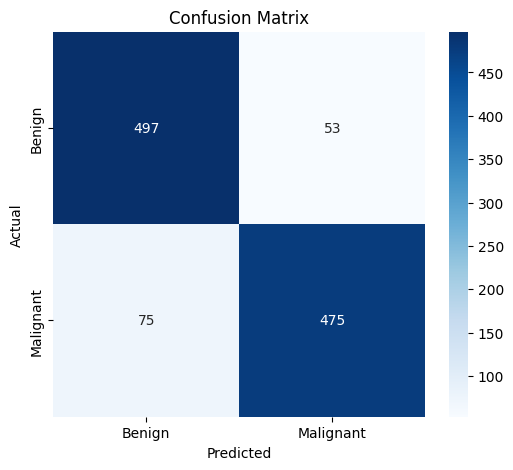

In [118]:
# Plot Confusion matrix
# Get predictions for val_loader
model.eval()
all_labels = []
all_preds = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device).float().unsqueeze(1)

        outputs = model(images)
        probs = torch.sigmoid(outputs)
        preds = (probs >= threshold).float()

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

# Compute confusion matrix
cm = confusion_matrix(all_labels, all_preds)
class_names = ["Benign", "Malignant"]

# Plot it
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
